# E34 · Bayesian synthetic control: reading a real media "natural experiment"

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Conjura's open multi-brand e-commerce MMM dataset (Anderson 2024, CC BY 4.0): one women's-apparel brand that stopped all Meta advertising on 10 October 2023, its US new customers for 125 weeks, and 21 weekly series of other brands as donors |
| **You will learn** | How to **find** a natural experiment in marketing data (change-point scan of channel spend) and how to judge it · classic **synthetic control** with simplex (Dirichlet) weights on the log scale · the **augmented / structural** version (CausalImpact, GeoLift): horseshoe regression on donors + a **random-walk level integrated out analytically** as a Gaussian process · why a latent-level version mixes badly · the counterfactual as a posterior predictive, effect = observed - counterfactual, weekly and cumulative · **placebo in time**, **placebo in space**, a **placebo outcome**, donor-pool sensitivity · cost per lost customer and "was switching off worth it?" as a probability · a placebo line-up and other displays for the people who decide |

The best evidence about what advertising does comes from switching it off. A randomised geo
experiment (GeoLift, Meta's and Google's lift tests) switches it off in some regions and
compares them with the rest. Most brands never run one - but many of them *do* switch
channels on and off, for their own reasons, and the data record it. A **synthetic control**
(Abadie, Diamond & Hainmueller 2010) turns such a switch into an estimate: build, from
series that were *not* switched, a weighted combination that tracks the switched series
before the switch, and read its continuation as "what would have happened otherwise".

The modern versions add two things. The **augmented** synthetic control (Ben-Michael, Feller
& Rothstein 2021) corrects the weighted combination with an outcome model, and Google's
**CausalImpact** (Brodersen et al. 2015) - the engine behind many marketing "incrementality"
reports - is a Bayesian structural time series: a regression on control series plus a local
level that absorbs what they miss. Both are a few lines of PyMC.

This is the third notebook of a media-measurement series. E32 showed that spend which chases
demand biases every regression of sales on spend; E33 built a hierarchical MMM and left the
question "is any of this causal?" to an experiment. Here there is no experiment, but there is
the next best thing - and the notebook is as much about **how far to trust it** as about the
estimate.

In [1]:
import json
import logging
import time
from pathlib import Path

import arviz as az
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import nutpie
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns
from matplotlib.patches import Ellipse, Rectangle

from pymc_challenges import data

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
BLUE, ORANGE, AQUA, GREY, PURPLE, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#d03b3b"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, nutpie {nutpie.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, nutpie 0.16.11


## 1 · Looking for a natural experiment

> *"We switched Meta off in October and nothing seemed to happen. Did we lose customers,
> how many, and would you have kept paying for them?"* - the question every brand that
> pauses a channel asks afterwards.

Conjura's dataset has 143 brand x territory daily series with spend by channel. A usable
natural experiment needs:

1. a **sharp, large** change: a channel family (Google, Meta or TikTok) going from almost
   every day to (almost) never, or the reverse, carrying a sizeable share of paid spend;
2. a **long clean pre-period** (at least ~6 months, ideally two Black Fridays) and enough
   weeks after;
3. **donors** that did not change at the same time, and no simultaneous discount event.

A crude but systematic scan: for every series and channel family, the share of days with
spend in the 8 weeks before each day versus the 8 weeks after; a jump of at least 0.8 is a
candidate switch. Google's sub-channels are pooled, because the scan otherwise finds
the mass migration from Shopping to Performance Max in July 2022 - a relabelling, not an
intervention.

In [2]:
data.describe("conjura_mmm")
raw = data.load("conjura_mmm")
raw["date"] = pd.to_datetime(raw["DATE_DAY"])
FAMILIES = {"Google": "^GOOGLE.*_SPEND", "Meta": "^META.*_SPEND", "TikTok": "^TIKTOK_SPEND"}
for fam, rx in FAMILIES.items():
    raw[fam] = raw.filter(regex=rx).fillna(0).sum(axis=1)
raw["paid"] = raw[list(FAMILIES)].sum(axis=1)

rows = []
for sid, g in raw.groupby("MMM_TIMESERIES_ID"):
    g = g.set_index("date").sort_index().asfreq("D")
    if len(g) < 300:
        continue
    paid = g["paid"].fillna(0)
    for fam in FAMILIES:
        s = g[fam].fillna(0)
        on = (s > 0).astype(float)
        step = on[::-1].rolling(56).mean()[::-1] - on.rolling(56).mean().shift(1)  # after - before
        for kind, day in [("on", step.idxmax()), ("off", step.idxmin())]:
            if pd.isna(day) or abs(step[day]) < 0.8:
                continue
            before = slice(day - pd.Timedelta(days=56), day - pd.Timedelta(days=1))
            after = slice(day, day + pd.Timedelta(days=55))
            level = s[after].mean() if kind == "on" else s[before].mean()
            rows.append({
                "series": sid[:8], "brand": g["ORGANISATION_ID"].dropna().iloc[0][:8],
                "territory": g["TERRITORY_NAME"].dropna().iloc[0], "currency": g["CURRENCY_CODE"].dropna().iloc[0],
                "channel": fam, "switch": kind, "date": day.date(),
                "days_before": (day - g.index[0]).days, "days_after": (g.index[-1] - day).days,
                "spend_per_day": round(level), "paid_before": round(paid[before].mean()),
                "paid_after": round(paid[after].mean()),
            })
cands = pd.DataFrame(rows)
cands["paid_change"] = (cands["paid_after"] / cands["paid_before"].clip(lower=1) - 1).round(2)
cands = cands[(cands.days_before >= 180) & (cands.days_after >= 60) & (cands.paid_change.abs() >= 0.5)
              & (cands.spend_per_day >= 100)]
print(f"{len(cands)} candidate switches (>= 180 days before, >= 60 after, paid spend changes by >= 50%)")
cands.sort_values("spend_per_day", ascending=False).reset_index(drop=True)

conjura_mmm: 132,759 brand x territory x day rows (143 anonymised series from 93 e-commerce brands, 2019-2024): first-time and all purchases (orders, units, original price, discount), and spend / clicks / impressions for Google (search, shopping, PMax, display, video), Meta (Facebook, Instagram, other) and TikTok, plus organic/direct/email/referral clicks. Missing spend means the brand did not use that channel.
  source: Anderson, A. (2024), Multi-Region Marketing Mix Modelling (MMM) Dataset for Several eCommerce Brands, Conjura, figshare, doi:10.6084/m9.figshare.25314841 (CC BY 4.0).
  url:    https://ndownloader.figshare.com/files/46779652


24 candidate switches (>= 180 days before, >= 60 after, paid spend changes by >= 50%)


,series,brand,territory,currency,channel,switch,date,days_before,days_after,spend_per_day,paid_before,paid_after,paid_change
0,6be01761,784d6aa3,All Territories,GBP,Meta,off,2023-10-10,1267,147,9684,11598,2361,-0.80
1,d0744083,784d6aa3,US,USD,Meta,off,2023-10-10,1267,147,5727,6316,605,-0.90
2,6b89cf94,784d6aa3,UK,GBP,Meta,off,2023-10-10,1267,121,4378,5814,1857,-0.68
3,af96a18c,7c374835,All Territories,AUD,Meta,on,2022-07-31,313,672,1094,589,1982,2.37
4,e7417caa,7c374835,Australia,AUD,Meta,on,2022-07-31,313,672,932,494,1696,2.43
5,0dabf1ec,0d1fc3f1,Australia,AUD,Google,off,2022-07-05,1076,113,893,893,0,-1.00
6,bff18058,8d28b004,All Territories,USD,Google,off,2023-06-26,293,328,875,6124,2999,-0.51
7,dd16aba6,76d1d35d,All Territories,GBP,Meta,off,2023-02-08,958,466,587,649,210,-0.68
8,1006734b,258af10b,All Territories,GBP,Meta,on,2020-11-10,201,811,534,444,1705,2.84
9,caf6f077,849e0a6b,All Territories,AUD,Meta,off,2023-03-24,289,435,433,522,95,-0.82


Two dozen candidates survive the filters. Reading down the list:

- **The top three rows are one decision.** A UK women's-apparel brand (`784d6aa3`) stopped
  all Meta advertising on 10 October 2023 in both of its markets, the US and the UK. In the
  US, Meta was about $5,700 a day and about 90% of paid spend; paid spend fell by 90%
  overnight. No other switch in the dataset moves as much money, and it comes with three and
  a half years of history before it.
- An Australian apparel brand (`7c374835`) *launched* Meta at the end of July 2022 - but it
  raised Google spend in the same weeks, and launched Meta in New Zealand too, so there is no
  within-brand donor and two channels changed at once.
- `0d1fc3f1` (Australia) switched *all* paid media off in July 2022 - and its data end 113 days
  later. A brand that stops everything and then leaves the dataset looks more like a business
  winding down (or a lost data feed) than a media decision.
- The rest are smaller (mostly a few hundred dollars a day), have less than a year of history
  before the switch, or pause for only a few weeks.

The Meta switch-off is the one to study. It is **not** a clean experiment, and it is worth
writing down why before looking at any result:

- the brand *chose* the date, presumably for a reason (budget, poor reported results) that
  may itself be related to where sales were heading;
- it switched off in **both** markets at once, so no series of the same brand is left as a
  control - the donors must come from other brands;
- the switch falls **just before Black Friday**, the one period where a wrong counterfactual
  is most expensive;
- in this dataset, missing spend means "channel not used"; a Meta account disconnected from
  Conjura would look exactly the same. The brand's data end in March 2024 (the dataset runs
  to June), so it left the platform a few months later. The dataset's convention is taken at
  face value here, and the caveat travels with every number below.
- the evidence on that last point cuts both ways. Meta's spend, clicks *and* impressions all
  become NaN (not 0) from 10 October, after a last day at about a third of normal spend -
  what a feed that broke mid-day would also produce. And in the same weeks this brand's
  Google PMax column alternates between NaN and $1,500-2,000 from one day to the next, so in
  these rows NaN often means "not recorded" rather than "not used". E35 uses the same brand
  and treats 9 October as the end of the Meta feed. Read the result below as "did anything
  detectable change when Meta vanished from the data?": a lost feed (spend carried on)
  predicts no change at all, and a real pause predicts a loss only if Meta was working.

In [3]:
TREATED_BRAND = "784d6aa3cda59f59f2400332b2420a49"
T0 = pd.Timestamp("2023-10-10")  # first day with no Meta spend (a Tuesday)
brand = raw[raw["ORGANISATION_ID"] == TREATED_BRAND]
print(brand[["ORGANISATION_VERTICAL", "ORGANISATION_SUBVERTICAL", "ORGANISATION_PRIMARY_TERRITORY_NAME",
             "ORGANISATION_MARKETING_SOURCES"]].drop_duplicates().to_string(index=False))
us = brand[brand["TERRITORY_NAME"] == "US"].set_index("date").sort_index()
around = pd.DataFrame({
    period: {
        "Meta $/day": us.loc[sl, "Meta"].mean(), "Google $/day": us.loc[sl, "Google"].mean(),
        "new customers/day": us.loc[sl, "FIRST_PURCHASES"].mean(),
        "returning orders/day": (us.loc[sl, "ALL_PURCHASES"] - us.loc[sl, "FIRST_PURCHASES"]).mean(),
        "discount % of list price": 100 * us.loc[sl, "ALL_PURCHASES_GROSS_DISCOUNT"].sum()
        / us.loc[sl, "ALL_PURCHASES_ORIGINAL_PRICE"].sum(),
    }
    for period, sl in [("8 weeks before", slice(T0 - pd.Timedelta(days=56), T0 - pd.Timedelta(days=1))),
                       ("8 weeks after", slice(T0, T0 + pd.Timedelta(days=55))),
                       ("same 8 weeks, 2022", slice(T0 - pd.Timedelta(days=364), T0 - pd.Timedelta(days=309)))]
}).round(1)
print(f"US data: {us.index[0].date()} to {us.index[-1].date()}")
around

ORGANISATION_VERTICAL ORGANISATION_SUBVERTICAL ORGANISATION_PRIMARY_TERRITORY_NAME ORGANISATION_MARKETING_SOURCES
              Apparel         Women's Clothing                                  UK                   Google, Meta
US data: 2020-04-21 to 2024-03-05


,8 weeks before,8 weeks after,"same 8 weeks, 2022"
Meta $/day,5726.5,0.0,7181.6
Google $/day,589.4,605.2,500.2
new customers/day,92.6,80.7,99.6
returning orders/day,72.9,82.6,89.6
discount % of list price,2.8,3.2,5.2


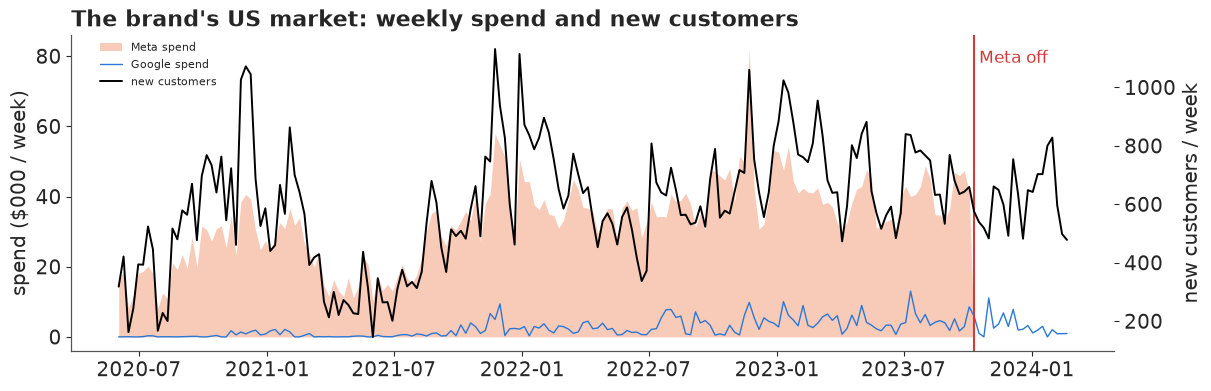

In [4]:
wk_us = us[["Meta", "Google", "FIRST_PURCHASES"]].resample("W-TUE", label="left", closed="left").sum()
wk_us = wk_us.loc["2020-06-01":"2024-02-26"]
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.fill_between(wk_us.index, wk_us["Meta"] / 1000, color=ORANGE, alpha=0.35, lw=0, label="Meta spend")
ax.plot(wk_us.index, wk_us["Google"] / 1000, color=BLUE, lw=1, label="Google spend")
ax.set_ylabel("spend ($000 / week)")
ax2 = ax.twinx()
ax2.plot(wk_us.index, wk_us["FIRST_PURCHASES"], color="k", lw=1.4, label="new customers")
ax2.set_ylabel("new customers / week")
ax2.grid(False)
ax.axvline(T0, color=RED, lw=1.5)
ax.text(T0, ax.get_ylim()[1] * 0.95, " Meta off", color=RED, va="top")
fig.legend(loc="upper left", bbox_to_anchor=(0.07, 0.93), fontsize=8)
ax.set_title("The brand's US market: weekly spend and new customers", loc="left");

In the US, the brand's Meta spend and its new customers moved together for three years -
which is exactly the ambiguity E32 was about: Meta may have been *buying* those customers,
or the brand may have spent more when demand was high anyway. The switch-off breaks that
link. Google carried on at about the same level (around $600 a day), and discounts stayed at
about 3% of list price, so the only big change on 10 October is Meta.

The naive readings already disagree. New customers per day fell from 93 in the 8 weeks
before to 81 in the 8 weeks after (-13%), and they were 100 a day in the same weeks of 2022.
But weeks differ for many reasons - the season, the brand's own drops and e-mails, a
different year - and a before/after or year-on-year comparison attributes all of them to
Meta. The counterfactual has to come from somewhere else.

## 2 · The donor pool

Donors are series from **other brands** whose new customers share the calendar (the same
Black Friday, Christmas and January sales) but were not touched by this brand's decision:

- US-dollar and sterling series (the US and UK retail calendars), complete from
  5 October 2021 to 26 February 2024;
- **no channel family switched** on or off in the 8 weeks around 10 October 2023 (share of
  days with spend changes by less than 0.25);
- **one series per brand** (a brand's "All Territories" row double-counts its markets), and
  no duplicates: three organisation IDs in the dataset carry the same daily series (a
  correlation of 1.00), so only one of them is kept.

The data are aggregated to **weeks running Tuesday to Monday**, so that the switch falls
exactly on a week boundary: 105 pre-period weeks (two Black Fridays) and 20 weeks after.
Weekly counts remove the day-of-week pattern and make a log-normal approximation for counts
of hundreds reasonable. The outcome is the log of weekly new customers.

In [5]:
START, END = pd.Timestamp("2021-10-05"), pd.Timestamp("2024-02-26")
win = raw[(raw["date"] >= START) & (raw["date"] <= END)].copy()
win["returning"] = win["ALL_PURCHASES"] - win["FIRST_PURCHASES"]
weekly = win.groupby(["MMM_TIMESERIES_ID", pd.Grouper(key="date", freq="W-TUE", label="left", closed="left")])[
    ["FIRST_PURCHASES", "returning"]].sum()
new_wk = weekly["FIRST_PURCHASES"].unstack(0)
ret_wk = weekly["returning"].unstack(0)
weeks = new_wk.index
n_days = (END - START).days + 1

info = []
for sid, g in win.groupby("MMM_TIMESERIES_ID"):
    g = g.set_index("date").sort_index()
    shares = [((g.loc[T0 - pd.Timedelta(days=56): T0 - pd.Timedelta(days=1), f] > 0).mean(),
               (g.loc[T0: T0 + pd.Timedelta(days=55), f] > 0).mean()) for f in FAMILIES]
    info.append({"sid": sid, "brand": g["ORGANISATION_ID"].iloc[0], "territory": g["TERRITORY_NAME"].iloc[0],
                 "currency": g["CURRENCY_CODE"].iloc[0], "vertical": g["ORGANISATION_VERTICAL"].iloc[0],
                 "complete": len(g) == n_days, "switch": max(abs(a - b) for a, b in shares)})
info = pd.DataFrame(info).set_index("sid")
pool = info[info.complete & info.currency.isin(["USD", "GBP"]) & (info.brand != TREATED_BRAND)
            & (info.switch < 0.25)].copy()
# one series per brand: prefer a territory over the "All Territories" aggregate
pool["agg"] = pool.territory == "All Territories"
pool = pool.sort_values("agg").groupby("brand").head(1)
# exact duplicates across organisation IDs (daily correlation of log counts > 0.99)
daily = np.log1p(win[win.MMM_TIMESERIES_ID.isin(pool.index)].pivot_table(
    index="date", columns="MMM_TIMESERIES_ID", values="FIRST_PURCHASES"))
corr = daily.corr()
dup = {b for a in corr.index for b in corr.columns if a < b and corr.loc[a, b] > 0.99}
pool = pool.drop(index=list(dup))
TREATED = info[(info.brand == TREATED_BRAND) & (info.territory == "US")].index[0]
DONORS = list(pool.sort_values(["currency", "vertical"]).index)
print(f"dropped as duplicates: {[d[:8] for d in dup]}")
print(f"{len(DONORS)} donors;", pool.groupby(["currency", "vertical"]).size().to_dict())

Y = np.log(new_wk[TREATED].to_numpy(float))            # treated: log weekly new customers
X = np.log(new_wk[DONORS].to_numpy(float))             # donors, (week, donor)
R = np.log(ret_wk[TREATED].clip(lower=1).to_numpy(float))    # treated brand's returning orders
RX = np.log(ret_wk[DONORS].clip(lower=1).to_numpy(float))
PRE = np.asarray(weeks < T0)
T, J = X.shape
POST = np.flatnonzero(~PRE)
donor_label = [f"{info.loc[d, 'vertical'][:14]} ({info.loc[d, 'currency']}) {d[:4]}" for d in DONORS]
print(f"{T} weeks: {PRE.sum()} before ({weeks[0].date()} to {weeks[PRE][-1].date()}), {(~PRE).sum()} after")

dropped as duplicates: ['c8c1146a']
21 donors; {('GBP', 'Apparel'): 3, ('GBP', 'Beauty & Fitness'): 1, ('GBP', 'Food & Drink'): 1, ('GBP', 'Health'): 1, ('GBP', 'Home & Garden'): 5, ('GBP', 'Toys & Hobbies'): 1, ('GBP', 'Travel'): 1, ('USD', 'Apparel'): 5, ('USD', 'Autos & Vehicles'): 1, ('USD', 'Beauty & Fitness'): 1, ('USD', 'Business & Industrial'): 1}
125 weeks: 105 before (2021-10-05 to 2023-10-03), 20 after


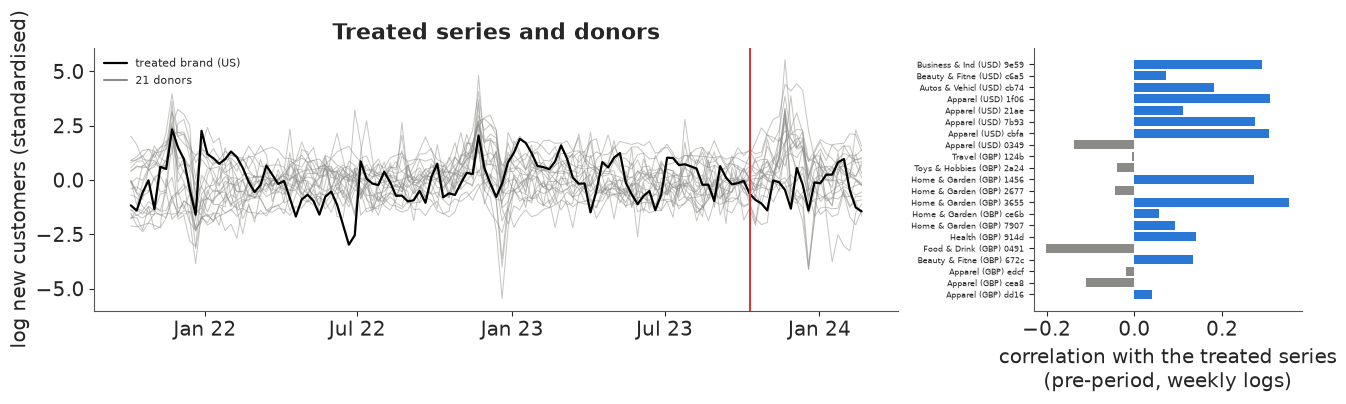

In [6]:
z = lambda a: (a - a[PRE].mean(0)) / a[PRE].std(0)
r_pre = np.array([np.corrcoef(Y[PRE], X[PRE, j])[0, 1] for j in range(J)])
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), width_ratios=[3, 1])
axes[0].plot(weeks, z(X), color=GREY, lw=0.7, alpha=0.5)
axes[0].plot(weeks, z(Y), color="k", lw=1.6, label="treated brand (US)")
axes[0].plot([], [], color=GREY, label="21 donors")
axes[0].axvline(T0, color=RED)
axes[0].set(ylabel="log new customers (standardised)", title="Treated series and donors")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
axes[0].legend(fontsize=8)
axes[1].barh(range(J), r_pre, color=np.where(r_pre > 0, BLUE, GREY))
axes[1].set(yticks=range(J), xlabel="correlation with the treated series\n(pre-period, weekly logs)")
axes[1].set_yticklabels(donor_label, fontsize=6);

This is the first warning. No donor tracks the treated brand well: the best pre-period
correlation of weekly log new customers is about 0.35, several are negative. The shared
calendar is visible - most donors jump at Black Friday - but this brand's weekly swings come
mostly from its own drops, campaigns and e-mails, and its Black Friday peak is much smaller
than most donors'. Classic synthetic control assumes the treated unit lies (roughly) inside
the convex hull of the donors. Here it does not, and the next section shows what that does.

## 3 · Classic synthetic control, the Bayesian way

Abadie's synthetic control writes the treated outcome before the switch as a **convex
combination** of donors: non-negative weights that sum to one, so the synthetic unit is an
interpolation of real units and never an extrapolation. On the log scale with each series
centred on its pre-period mean (the "de-meaned" SC of Doudchenko & Imbens 2016 and Ferman &
Pinto 2021, which lets a big brand be matched by small ones):

$$\tilde y_t = \alpha + \sum_j w_j \tilde x_{jt} + \varepsilon_t, \qquad
  w \sim \text{Dirichlet}(1, \dots, 1), \qquad \varepsilon_t \sim t_\nu(0, \sigma).$$

The Bayesian version gives a posterior over the weights rather than one optimised vector, and
the counterfactual after the switch is the posterior predictive of $\tilde y_t$ given the
donors' observed values. Only pre-period weeks enter the likelihood.

**One modelling trick used throughout.** Every model below is built on all 125 weeks with a
`mask` that switches the likelihood on for the weeks used to fit. A placebo "switch" at an
earlier date, or a donor playing the treated unit, only changes the *data* - not a shape - so
the model is compiled once by nutpie and re-used with `compiled.with_data(...)`: about 40 fits
cost 40 samplings, not 40 compilations.

In [7]:
def centre(y, X, pre):
    """Centre the log target and donors on their pre-period means; donors also scaled (for regressions)."""
    Xc = X - X[pre].mean(0)
    return y - y[pre].mean(), Xc, Xc / X[pre].std(0)


def build_sc(yc, Xc, pre):
    with pm.Model() as m:
        y = pm.Data("y", yc)
        Xd = pm.Data("X", Xc)
        mask = pm.Data("mask", pre.astype(float))
        w = pm.Dirichlet("w", a=np.ones(Xc.shape[1]))
        alpha = pm.Normal("alpha", 0, 0.2)
        sigma = pm.HalfNormal("sigma", 0.3)
        nu = pm.Gamma("nu", 2, 0.1)
        mu = pm.Deterministic("mu", alpha + Xd @ w)
        pm.Potential("lik", (mask * pm.logp(pm.StudentT.dist(nu=nu, mu=mu, sigma=sigma), y)).sum())
    return m


def fit(compiled, seed, draws=1000, **data_):
    """Sample a compiled nutpie model on new data (4 chains, run as threads in one process)."""
    cm = compiled.with_data(**data_) if data_ else compiled
    return nutpie.sample(cm, chains=4, draws=draws, seed=seed, progress_bar=False, target_accept=0.95)


def sc_draws(idata, seed, n=1000):
    """Posterior predictive draws of the centred log outcome at every week (mu + Student-t noise)."""
    r = np.random.default_rng(seed)
    mu = idata.posterior["mu"].to_numpy().reshape(-1, T)
    sig, nu = idata.posterior["sigma"].to_numpy().ravel(), idata.posterior["nu"].to_numpy().ravel()
    k = r.choice(len(sig), n, replace=False)
    return mu[k] + sig[k, None] * r.standard_t(nu[k, None], size=(n, T))


def diagnose(idata, names, label):
    s = az.summary(idata, var_names=names, round_to=3)
    rh, ess = az.rhat(idata), az.ess(idata)
    print(f"{label}: divergences {int(idata.sample_stats['diverging'].sum())}, "
          f"max r_hat {max(float(rh[v].max()) for v in rh.data_vars):.3f}, "
          f"min bulk ESS {min(float(ess[v].min()) for v in ess.data_vars):.0f} (all variables)")
    return s


yc, Xc, Xs = centre(Y, X, PRE)
t_ = time.time()
sc_model = nutpie.compile_pymc_model(build_sc(yc, Xc, PRE))
idata_sc = fit(sc_model, RANDOM_SEED)
print(f"compile + sample: {time.time() - t_:.0f} s")
diagnose(idata_sc, ["alpha", "sigma", "nu"], "synthetic control")

compile + sample: 4 s
synthetic control: divergences 0, max r_hat 1.004, min bulk ESS 1481 (all variables)


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.002,0.022,-0.032,0.037,7019.785,2802.868,1.001,0.0,0.000
sigma,0.206,0.018,0.178,0.234,4208.500,2966.691,1.001,0.0,0.000
nu,24.190,14.133,7.919,50.660,5179.537,3275.366,1.000,0.2,0.304


In [8]:
w_mean = idata_sc.posterior["w"].mean(("chain", "draw")).to_numpy()
top = np.argsort(w_mean)[::-1][:6]
pd.DataFrame({"donor": [donor_label[j] for j in top], "weight (mean)": w_mean[top].round(3),
              "90% interval": [np.quantile(idata_sc.posterior["w"].to_numpy()[..., j], [0.05, 0.95]).round(2)
                               for j in top]})

,donor,weight (mean),90% interval
0,Home & Garden (GBP) 1456,0.205,"[0.05, 0.36]"
1,Autos & Vehicl (USD) cb74,0.125,"[0.01, 0.27]"
2,Home & Garden (GBP) 3655,0.081,"[0.01, 0.17]"
3,Health (GBP) 914d,0.067,"[0.01, 0.15]"
4,Apparel (USD) cbfa,0.060,"[0.01, 0.12]"
5,Apparel (GBP) dd16,0.056,"[0.01, 0.13]"


Before reading any effect, the pre-period fit: the whole point of a synthetic control is that
it *tracks the treated unit before the switch*. The effect is summarised as the change in
total new customers over the 20 post-period weeks, in percent of the counterfactual:
$\sum_t (y_t - \hat y_t) / \sum_t \hat y_t$ on the count scale, with $\hat y$ drawn from the
posterior predictive.

pre-period weeks inside the 90% band: 93%; pre-period RMSE (log): 0.21; P(effect < 0) = 1.000


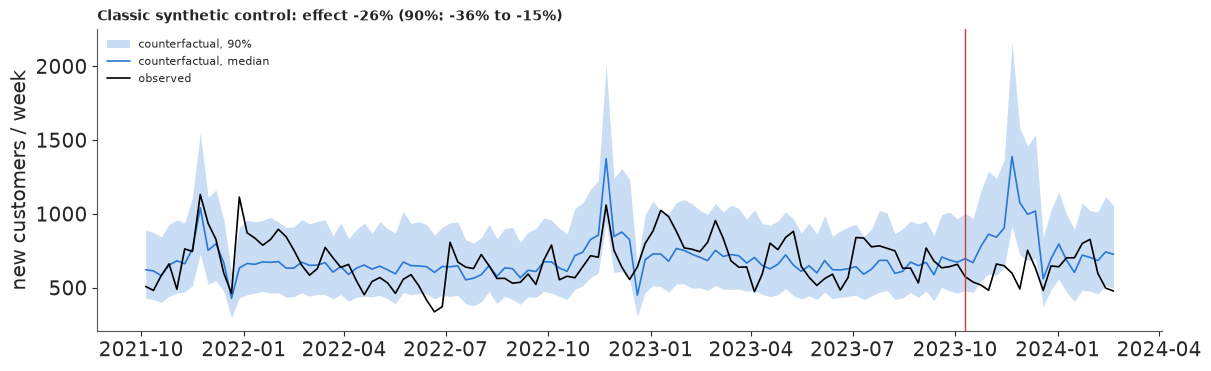

In [9]:
def to_counts(draws, y):
    """Centred log draws -> weekly counts on the original scale."""
    return np.exp(draws + y[PRE].mean())


def effect_pct(cf_counts, y, idx):
    obs = np.exp(y[idx]).sum()
    return (obs - cf_counts[:, idx].sum(axis=1)) / cf_counts[:, idx].sum(axis=1)


def fan(ax, cf_counts, y, title, color=BLUE):
    ax.fill_between(weeks, *np.quantile(cf_counts, [0.05, 0.95], axis=0), color=color, alpha=0.25, lw=0,
                    label="counterfactual, 90%")
    ax.plot(weeks, np.median(cf_counts, axis=0), color=color, lw=1.2, label="counterfactual, median")
    ax.plot(weeks, np.exp(y), color="k", lw=1.2, label="observed")
    ax.axvline(T0, color=RED, lw=1)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_ylabel("new customers / week")


cf_sc = to_counts(sc_draws(idata_sc, 1), Y)
pct_sc = effect_pct(cf_sc, Y, POST)
inside = lambda cf: np.mean((np.exp(Y[PRE]) >= np.quantile(cf[:, PRE], 0.05, axis=0))
                            & (np.exp(Y[PRE]) <= np.quantile(cf[:, PRE], 0.95, axis=0)))
fig, ax = plt.subplots(figsize=(12, 3.6))
fan(ax, cf_sc, Y, f"Classic synthetic control: effect {np.median(pct_sc):+.0%} "
                  f"(90%: {np.quantile(pct_sc, 0.05):+.0%} to {np.quantile(pct_sc, 0.95):+.0%})")
ax.legend(fontsize=8, loc="upper left");
print(f"pre-period weeks inside the 90% band: {inside(cf_sc):.0%}; "
      f"pre-period RMSE (log): {np.sqrt(np.mean((Y[PRE] - np.log(np.median(cf_sc[:, PRE], 0))) ** 2)):.2f}; "
      f"P(effect < 0) = {(pct_sc < 0).mean():.3f}")

The Bayesian machinery works - no divergences, r_hat 1.00, large ESS - and the answer looks
decisive: **a 26% drop, with a 90% interval of -36% to -15% and P(effect < 0) = 1.00**. It
should not be believed, and the figure says why:

- The weights are spread thinly over many donors (the largest, a home-and-garden brand
  reporting in sterling, gets about 0.2), and the synthetic series is nearly **flat** - it averages away the
  donors' idiosyncrasies and with them most of the treated brand's movements. The pre-period
  error is about 21% per week on the log scale.
- Where the donors do move together, at **Black Friday**, the synthetic series overshoots: it
  predicted a much bigger November 2022 peak than the brand had, and it predicts one again in
  November 2023. A good part of the "effect" is that missing peak.
- The iid noise term treats a run of ten bad weeks as ten independent accidents, so the
  20-week sum looks far more certain than it is. The pre-period band covers 93% of weeks,
  which looks calibrated week by week; the problem is in the *sum*.

A pre-period fit this poor would stop a classic SC analysis before any effect is reported
(Abadie 2021 is explicit about that). Section 6 checks the claim with placebos.

## 4 · The augmented / structural model

CausalImpact's answer to "the donors miss things" is to add a **local level**, a random walk
$\ell_t = \ell_{t-1} + \eta_t$, $\eta_t \sim N(0, \sigma_\ell)$, that follows whatever the
donors cannot explain, and to replace the simplex by a **sparse regression** on (scaled)
donors - spike-and-slab in CausalImpact, a regularised **horseshoe** here (Piironen & Vehtari
2017), with a global scale set for about three relevant donors out of 21:

$$\tilde y_t = \ell_t + \sum_j \beta_j x^{s}_{jt} + \gamma\, r_t + \varepsilon_t,
  \qquad \varepsilon_t \sim N(0, \sigma).$$

Two versions: **augmented** (donors + level) and **augmented + own control series**, which
also uses $r_t$, the treated brand's own **returning-customer orders** (standardised log). The
idea is CausalImpact's: a series of the *same* unit that the intervention should not move.
Meta prospecting ads mostly buy *new* customers; returning orders are driven by the brand's
own drops, e-mails and sales, which also drive new customers. This is an assumption, and
section 6 tests it.

**Integrating out the level.** A random walk with an uncertain start is a Gaussian process
with covariance $s_0^2 + \sigma_\ell^2 \min(s, t)$ (Brownian motion). With Gaussian noise,
the level can be integrated out exactly: the pre-period observations are one multivariate
normal with covariance $s_0^2 + \sigma_\ell^2 \min(s,t) + \sigma^2 \delta_{st}$, and NUTS
samples only the ~45 regression and scale parameters instead of 125 extra level values. After
sampling, the level is recovered draw by draw from the Gaussian conditional - including its
continuation into the post-period, which is exactly the counterfactual forecast. The masked
weeks get an identity block in the covariance, which adds a constant to the log-density.

In [10]:
S0 = 0.5  # prior sd of the level in the first week (log scale, centred series)


def build_aug(yc, Xs, pre, Zr=None):
    idx = np.arange(T)
    MIN = np.minimum.outer(idx, idx).astype(float)
    n_pre, J_ = pre.sum(), Xs.shape[1]
    with pm.Model() as m:
        mask = pm.Data("mask", pre.astype(float))
        y = pm.Data("y", yc * pre)
        Xd = pm.Data("X", Xs)
        # regularised horseshoe: global scale for ~3 active donors, slab sd 0.1 on the log scale
        tau = pm.HalfCauchy("tau", 3 / (J_ - 3) * 0.3 / np.sqrt(n_pre))
        lam = pm.HalfCauchy("lam", 1, shape=J_)
        c2 = pm.InverseGamma("c2", 2, 2 * 0.1**2)
        lam_t = pt.sqrt(c2 * lam**2 / (c2 + tau**2 * lam**2))
        beta = pm.Deterministic("beta", pm.Normal("z", 0, 1, shape=J_) * tau * lam_t)
        mu = Xd @ beta
        if Zr is not None:
            Zd = pm.Data("Z", Zr)
            mu = mu + pm.Normal("gamma", 0, 0.5) * Zd
        mu = pm.Deterministic("mu", mu)
        sigma_level = pm.HalfNormal("sigma_level", 0.1)
        sigma = pm.HalfNormal("sigma", 0.3)
        K = S0**2 + sigma_level**2 * MIN + sigma**2 * np.eye(T)
        mm = mask[:, None] * mask[None, :]
        pm.MvNormal("y_obs", mu=mu * mask, cov=mm * K + (1 - mm) * pt.eye(T), observed=y)
    return m


def aug_draws(idata, yc, pre, seed, n=1000):
    """Counterfactual draws (centred log) at every week: level | pre-period residuals, plus noise."""
    r = np.random.default_rng(seed)
    post = idata.posterior
    mu = post["mu"].to_numpy().reshape(-1, T)
    sl, sg = post["sigma_level"].to_numpy().ravel(), post["sigma"].to_numpy().ravel()
    idx = np.arange(T)
    MIN = np.minimum.outer(idx, idx).astype(float)
    O = np.flatnonzero(pre)
    out = np.empty((n, T))
    for k, i in enumerate(r.choice(len(sl), n, replace=False)):
        Kaa = S0**2 + sl[i] ** 2 * MIN
        L = np.linalg.cholesky(Kaa[np.ix_(O, O)] + sg[i] ** 2 * np.eye(len(O)))
        A = np.linalg.solve(L, Kaa[O, :])
        mean = A.T @ np.linalg.solve(L, yc[O] - mu[i, O])
        Lc = np.linalg.cholesky(Kaa - A.T @ A + 1e-9 * np.eye(T))
        out[k] = mu[i] + mean + Lc @ r.standard_normal(T) + sg[i] * r.standard_normal(T)
    return out

**Prior predictive, in words a marketer can check.** Two priors carry the story. The level's
step size $\sigma_\ell \sim$ HalfNormal(0.1) decides how far the counterfactual may drift in
20 weeks without the donors' say-so; the horseshoe decides how many donors can matter.
Both are simulated directly:

In [11]:
p_sl = np.abs(rng.normal(0, 0.1, 4000))
drift20 = np.exp(p_sl * np.sqrt(20) * rng.standard_normal(4000)) - 1
tau0 = 3 / (J - 3) * 0.3 / np.sqrt(PRE.sum())
p_tau = np.abs(tau0 * rng.standard_cauchy(4000))
p_lam = np.abs(rng.standard_cauchy((4000, J)))
p_c2 = 1 / rng.gamma(2, 1 / (2 * 0.1**2), 4000)
lam_t = np.sqrt(p_c2[:, None] * p_lam**2 / (p_c2[:, None] + p_tau[:, None] ** 2 * p_lam**2))
kappa = 1 / (1 + PRE.sum() / 0.3**2 * (p_tau[:, None] * lam_t) ** 2)  # shrinkage factor per donor
m_eff = (1 - kappa).sum(axis=1)
print("prior: level drift over 20 weeks, 5/50/95%:", np.quantile(drift20, [0.05, 0.5, 0.95]).round(2))
print("prior: effective number of active donors, 5/50/95%:", np.quantile(m_eff, [0.05, 0.5, 0.95]).round(1))

prior: level drift over 20 weeks, 5/50/95%: [-0.51 -0.    1.09]
prior: effective number of active donors, 5/50/95%: [ 0.1  2.8 14. ]


The level prior lets the counterfactual drift anywhere from about halving to doubling over
20 weeks (5% to 95%) - generous, but this brand's own history contains moves of that size
within a few months (spring 2021 in the first figure). The horseshoe says "about three donors
matter" (median effective number about 3) while allowing none or many.

**Why not a latent level?** The textbook way writes the level as 125 latent variables
(non-centred: $\ell = \sigma_\ell \cdot \text{cumsum}(z)$). It works on these data, but the
observation noise and the level's step size trade off against each other - a noisy week can
be a level move or a blip - and NUTS pays for that ridge. One fit of each, same data, same
sampler settings:

In [12]:
def build_latent(yc, Xs, pre, Zr):
    n_pre, J_ = pre.sum(), Xs.shape[1]
    with pm.Model() as m:
        tau = pm.HalfCauchy("tau", 3 / (J_ - 3) * 0.3 / np.sqrt(n_pre))
        lam = pm.HalfCauchy("lam", 1, shape=J_)
        c2 = pm.InverseGamma("c2", 2, 2 * 0.1**2)
        lam_t = pt.sqrt(c2 * lam**2 / (c2 + tau**2 * lam**2))
        beta = pm.Normal("z", 0, 1, shape=J_) * tau * lam_t
        sigma_level = pm.HalfNormal("sigma_level", 0.1)
        level = S0 * pm.Normal("l0", 0, 1) + sigma_level * pt.cumsum(pm.Normal("eps", 0, 1, shape=T))
        mu = level + Xs @ beta + pm.Normal("gamma", 0, 0.5) * Zr
        pm.Normal("y_obs", mu[pre], pm.HalfNormal("sigma", 0.3), observed=yc[pre])
    return m


Zr = (R - R[PRE].mean()) / R[PRE].std()
aug_model = nutpie.compile_pymc_model(build_aug(yc, Xs, PRE))
own_model = nutpie.compile_pymc_model(build_aug(yc, Xs, PRE, Zr))
cmp_rows = {}
for label, cm in [("latent level (125 extra variables)", nutpie.compile_pymc_model(build_latent(yc, Xs, PRE, Zr))),
                  ("level integrated out", own_model)]:
    t_ = time.time()
    idt = fit(cm, RANDOM_SEED)
    sec = time.time() - t_
    ess = az.ess(idt, var_names=["sigma", "sigma_level"])
    cmp_rows[label] = {"divergences": int(idt.sample_stats["diverging"].sum()),
                       "max r_hat (sigma, sigma_level)": max(float(az.rhat(idt, var_names=[v])[v]) for v in ["sigma", "sigma_level"]),
                       "ESS sigma_level": float(ess["sigma_level"]), "ESS sigma": float(ess["sigma"]),
                       "seconds": sec, "ESS sigma_level / s": float(ess["sigma_level"]) / sec}
idata_own = idt
pd.DataFrame(cmp_rows).T.round(2)

,divergences,"max r_hat (sigma, sigma_level)",ESS sigma_level,ESS sigma,seconds,ESS sigma_level / s
latent level (125 extra variables),142.0,1.03,185.11,172.27,2.14,86.70
level integrated out,2.0,1.00,1328.71,1176.22,8.65,153.65


The latent version has over a hundred divergences and an ESS below 200 for the two scales,
because the sampler has to walk along the ridge where noise and level variance trade off.
With the level integrated out, the same posterior is sampled with a couple of divergences
and an ESS above 1,000. Each gradient is more expensive (a 125 x 125 Cholesky), but the
effective samples per second still come out about twice as high. This is what state-space
software does with a Kalman filter; for a series of a hundred weeks the dense Gaussian
process form is simpler and fast enough. (The few remaining divergences sit in the
horseshoe's funnel; they stay a handful per fit at `target_accept=0.95`.)

In [13]:
idata_aug = fit(aug_model, RANDOM_SEED)
s_aug = diagnose(idata_aug, ["sigma", "sigma_level", "tau"], "augmented")
s_own = diagnose(idata_own, ["sigma", "sigma_level", "tau", "gamma"], "augmented + own control series")
s_own

augmented: divergences 1, max r_hat 1.011, min bulk ESS 324 (all variables)


augmented + own control series: divergences 2, max r_hat 1.004, min bulk ESS 1176 (all variables)


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma,0.090,0.026,0.044,0.126,1176.220,1027.952,1.002,0.001,0.001
sigma_level,0.099,0.027,0.057,0.143,1328.713,1203.088,1.001,0.001,0.000
tau,0.004,0.004,0.000,0.010,1601.992,1698.398,1.000,0.000,0.000
gamma,0.155,0.021,0.122,0.188,5075.962,3093.825,1.000,0.000,0.000


 synthetic control: pre-period weeks inside 90% band 93%; effect median -25.7%, P(effect < 0) = 1.00
         augmented: pre-period weeks inside 90% band 100%; effect median -14.5%, P(effect < 0) = 0.69
   augmented + own: pre-period weeks inside 90% band 100%; effect median -12.6%, P(effect < 0) = 0.70
donors with |beta| > 0.02 in more than half of the draws: []


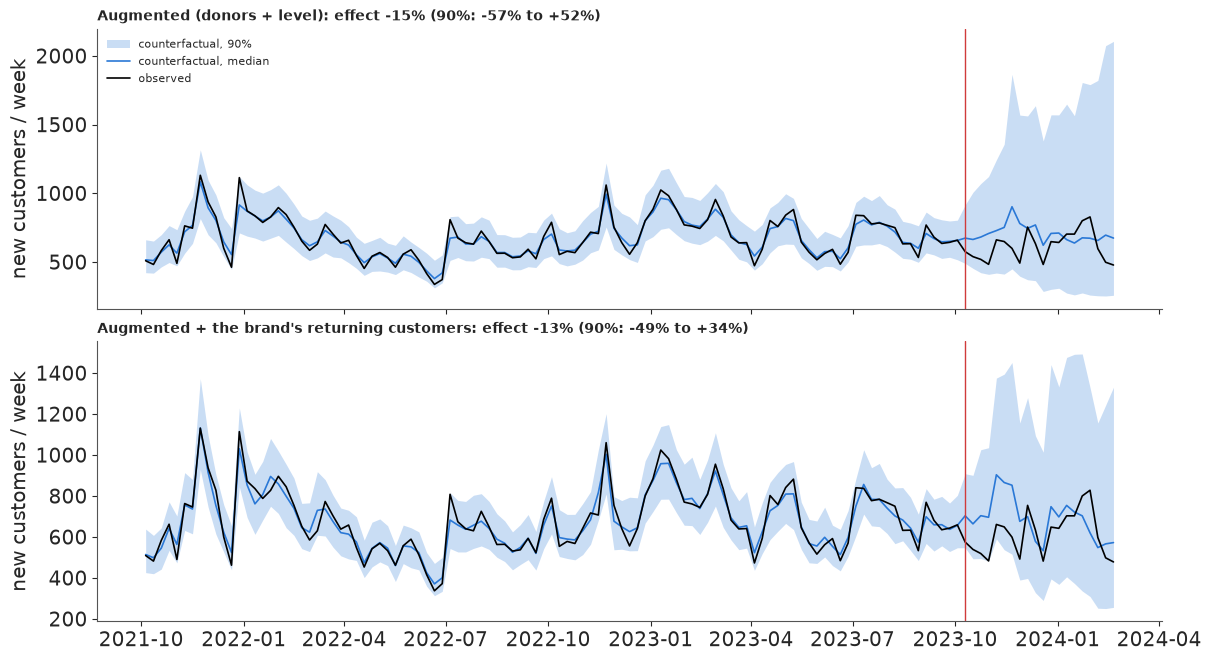

In [14]:
cf_aug = to_counts(aug_draws(idata_aug, yc, PRE, 2), Y)
cf_own = to_counts(aug_draws(idata_own, yc, PRE, 3), Y)
pct_aug, pct_own = effect_pct(cf_aug, Y, POST), effect_pct(cf_own, Y, POST)
fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
for ax, cf, pc, name in [(axes[0], cf_aug, pct_aug, "Augmented (donors + level)"),
                         (axes[1], cf_own, pct_own, "Augmented + the brand's returning customers")]:
    fan(ax, cf, Y, f"{name}: effect {np.median(pc):+.0%} "
                   f"(90%: {np.quantile(pc, 0.05):+.0%} to {np.quantile(pc, 0.95):+.0%})")
axes[0].legend(fontsize=8, loc="upper left")
for name, cf, pc in [("synthetic control", cf_sc, pct_sc), ("augmented", cf_aug, pct_aug),
                     ("augmented + own", cf_own, pct_own)]:
    print(f"{name:>18}: pre-period weeks inside 90% band {inside(cf):.0%}; "
          f"effect median {np.median(pc):+.1%}, P(effect < 0) = {(pc < 0).mean():.2f}")
beta_own = idata_own.posterior["beta"].to_numpy().reshape(-1, J)
print("donors with |beta| > 0.02 in more than half of the draws:",
      [donor_label[j] for j in np.flatnonzero((np.abs(beta_own) > 0.02).mean(0) > 0.5)])

Three things changed compared with the classic control.

- **The donors are switched off by the data.** The horseshoe shrinks every donor coefficient
  to nearly zero - no donor has a coefficient above 0.02 in more than half of the draws. After
  the level has absorbed the slow movements, the donors add nothing the pre-period can
  confirm. This is the honest version of the previous section's warning.
- **The level follows the brand**, and the brand's own returning orders explain part of its
  weekly swings: one standard deviation more returning orders goes with about 16% more new
  customers (gamma about 0.16, well away from zero). The pre-period band covers every week,
  but that is an in-sample check - the level is fitted *to* those weeks. The real test of
  this model is out of sample: the placebos in section 6.
- **The fan opens after the switch.** A random walk has nothing to hold it once the data stop,
  so by February the plausible counterfactual ranges from about 300 to 1,300 new customers a
  week. That is not a defect of the model; it is how much a 20-week forecast of this brand's
  new customers is actually worth.

The estimate: **about -13% (augmented + own series; 90% interval roughly -50% to +35%;
P(effect < 0) about 0.7)**, and about -15% with a still wider interval without the own
series. The classic control's -26% is inside both intervals; its certainty is not. The rest of
the notebook uses the augmented + own model.

## 5 · The effect, in customers and in dollars

Effect per week = observed - counterfactual, on the count scale, draw by draw; the
cumulative effect adds the weeks up. The dollar side needs a counterfactual for **spend**
too: what would Meta have cost if it had stayed on? Two anchors: the brand's US Meta spend
in the 8 weeks before the switch, carried forward for 20 weeks; and its Meta spend in the
same 20 weeks a year earlier (which includes the Black Friday push).

In [15]:
meta_rate = us.loc[T0 - pd.Timedelta(days=56): T0 - pd.Timedelta(days=1), "Meta"].mean() * 7
last_year = us.loc[T0 - pd.Timedelta(days=364): T0 - pd.Timedelta(days=364) + pd.Timedelta(weeks=20, days=-1), "Meta"].sum()
SAVED = {"8-week run rate": meta_rate * len(POST), "same weeks last year": last_year}
blended_cac = (us.loc[T0 - pd.Timedelta(days=56): T0 - pd.Timedelta(days=1), "paid"].sum()
               / us.loc[T0 - pd.Timedelta(days=56): T0 - pd.Timedelta(days=1), "FIRST_PURCHASES"].sum())
print({k: f"${v:,.0f}" for k, v in SAVED.items()}, f"| blended cost per new customer before: ${blended_cac:.0f}")

lost = cf_own[:, POST] - np.exp(Y[POST])        # customers lost per week (positive = lost)
lost_cum = lost.cumsum(axis=1)
LOST = lost_cum[:, -1]
q = lambda a, p=(0.05, 0.5, 0.95): np.quantile(a, p)
print(f"customers lost in 20 weeks: median {np.median(LOST):,.0f}, 90% {q(LOST)[0]:,.0f} to {q(LOST)[2]:,.0f}; "
      f"P(lost > 0) = {(LOST > 0).mean():.2f}; observed {np.exp(Y[POST]).sum():,.0f}")
per10k = LOST / (SAVED["8-week run rate"] / 10_000)
print(f"customers lost per $10,000 not spent: median {np.median(per10k):.1f}, 90% {q(per10k)[0]:.1f} to {q(per10k)[2]:.1f}")
for k, v in SAVED.items():
    cpl = v / LOST[LOST > 0]  # only defined when customers were lost
    print(f"{k}: if customers were lost, cost per lost customer median ${np.median(cpl):,.0f} "
          f"(90% ${q(cpl)[0]:,.0f} to ${q(cpl)[2]:,.0f}); P(Meta's customers cost more than the blended "
          f"${blended_cac:.0f}, or Meta bought none) = {(LOST < v / blended_cac).mean():.2f}")

{'8-week run rate': '$801,715', 'same weeks last year': '$922,086'} | blended cost per new customer before: $68
customers lost in 20 weeks: median 1,765, 90% -3,106 to 11,572; P(lost > 0) = 0.70; observed 12,284
customers lost per $10,000 not spent: median 22.0, 90% -38.7 to 144.3
8-week run rate: if customers were lost, cost per lost customer median $244 (90% $63 to $2,083); P(Meta's customers cost more than the blended $68, or Meta bought none) = 0.95
same weeks last year: if customers were lost, cost per lost customer median $280 (90% $72 to $2,396); P(Meta's customers cost more than the blended $68, or Meta bought none) = 0.97


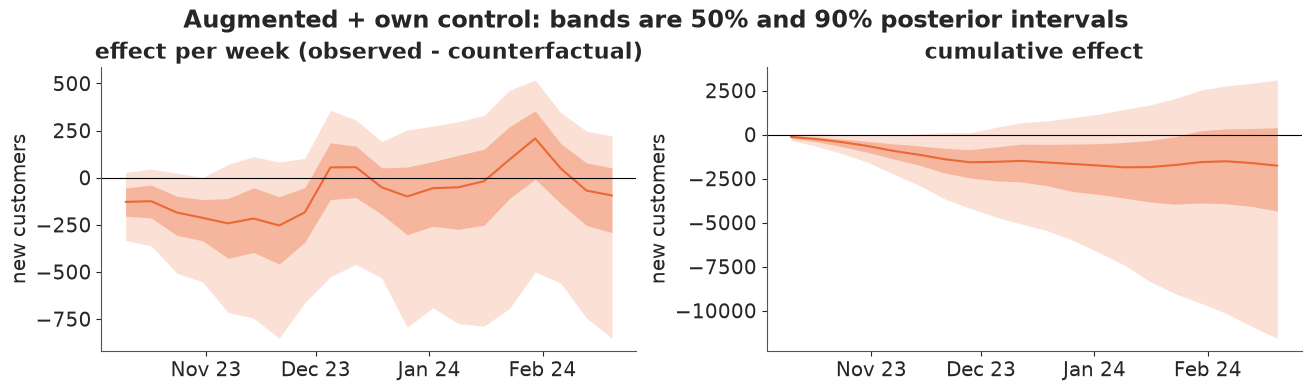

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
wk_post = weeks[POST]
for ax, a, lab in [(axes[0], -lost, "effect per week (observed - counterfactual)"),
                   (axes[1], -lost_cum, "cumulative effect")]:
    for lo_, hi_, al in [(0.05, 0.95, 0.2), (0.25, 0.75, 0.35)]:
        ax.fill_between(wk_post, *np.quantile(a, [lo_, hi_], axis=0), color=ORANGE, alpha=al, lw=0)
    ax.plot(wk_post, np.median(a, axis=0), color=ORANGE)
    ax.axhline(0, color="k", lw=0.8)
    ax.set(title=lab, ylabel="new customers")
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.suptitle("Augmented + own control: bands are 50% and 90% posterior intervals");

In customers: the brand acquired about 12,300 new US customers in the 20 weeks after the
switch; the model's best estimate is that it would have acquired about 1,800 more with Meta
on, but the 90% interval runs from about 3,000 *more* to about 11,500 *fewer* than observed,
and the chance that any customers were lost at all is about 70%.

The weekly effect has a shape: most of the (probable) loss happens in the first eight weeks,
through Black Friday, where the 50% band stays below zero; from mid-December the weekly
effect wanders around zero. That is what a channel with a short carry-over would look like
- or what a counterfactual that overshoots Black Friday would look like.

In dollars the picture is sharper than in customers, because the saving was large: about
$800,000 of Meta spend at the pre-switch run rate (about $920,000 at last year's spend for the
same weeks), against about 22 customers lost per $10,000 not spent (median). If Meta had been
buying customers at the brand's blended $68, switching off would have cost roughly 11,800
customers; the posterior puts about 95% of its mass below that. In other words: **either
Meta was buying few customers here, or it was buying them at well over $100 each** (median
about $240 per lost customer, given that some were lost).

## 6 · Would we have believed an effect? Placebos

A synthetic control with a good-looking fan is not yet evidence. Three placebo checks, all
the same procedure applied where we *know* there was no Meta switch:

1. **In time**: pretend the switch happened on a date inside the pre-period (every 4 weeks
   from October 2022 to May 2023), fit on the weeks before it and predict the next 20. The
   true effect is zero, so the 90% interval should contain zero about 9 times in 10, and the
   estimates should be small.
2. **In space**: make each donor in turn the "treated" unit (with the other 20 as its donors
   and its own returning customers as its control series) and estimate its "effect" of
   10 October 2023. This gives the distribution of effects that arise **without** any
   switch - the reference against which the real estimate is judged (Abadie's permutation
   inference).
3. **A placebo outcome**: run the augmented model on the brand's *returning* orders. If the
   switch-off moved them, they were not a valid control series.

In [17]:
def run(model_kind, y, Xd, r, pre, seed, draws=400):
    """One fit of a model on (target y, donors Xd, own series r, fit weeks pre); counterfactual counts."""
    yc_, Xc_, Xs_ = centre(y, Xd, pre)
    if model_kind == "sc":
        idt = fit(COMPILED[("sc", Xd.shape[1])], seed, draws, y=yc_, X=Xc_, mask=pre.astype(float))
        cf = sc_draws(idt, seed, 500)
    else:
        upd = dict(y=yc_ * pre, X=Xs_, mask=pre.astype(float))
        if model_kind == "own":
            upd["Z"] = (r - r[pre].mean()) / r[pre].std()
        idt = fit(COMPILED[(model_kind, Xd.shape[1])], seed, draws, **upd)
        cf = aug_draws(idt, yc_, pre, seed, 500)
    return np.exp(cf + y[pre].mean()), int(idt.sample_stats["diverging"].sum())


COMPILED = {("sc", J): sc_model, ("aug", J): aug_model, ("own", J): own_model}
t_ = time.time()
H = len(POST)
fake_dates = weeks[52: PRE.sum() - H + 1: 4]
rows = []
for f in fake_dates:
    pre_f = np.asarray(weeks < f)
    win_f = np.flatnonzero(~pre_f)[:H]
    for kind in ["sc", "aug", "own"]:
        cf, div = run(kind, Y, X, R, pre_f, 7)
        e = effect_pct(cf, Y, win_f)
        rows.append({"fake switch": f.date(), "model": kind, "median": np.median(e), "q05": q(e)[0],
                     "q95": q(e)[2], "divergences": div})
tp = pd.DataFrame(rows)
tp["covers 0"] = (tp.q05 < 0) & (tp.q95 > 0)
print(f"{len(tp)} placebo-in-time fits in {time.time() - t_:.0f} s; divergences in total: {tp.divergences.sum()}")
tp_sum = tp.groupby("model", sort=False).agg(**{
    "90% interval covers 0": ("covers 0", "mean"), "mean |estimate|": ("median", lambda s: s.abs().mean()),
    "mean interval width": ("q95", lambda s: (s - tp.loc[s.index, "q05"]).mean())}).round(2)
tp_sum.index = ["synthetic control", "augmented", "augmented + own"]
tp_sum

27 placebo-in-time fits in 100 s; divergences in total: 4


,90% interval covers 0,mean |estimate|,mean interval width
synthetic control,0.78,0.12,0.33
augmented,1.00,0.19,1.10
augmented + own,1.00,0.15,0.98


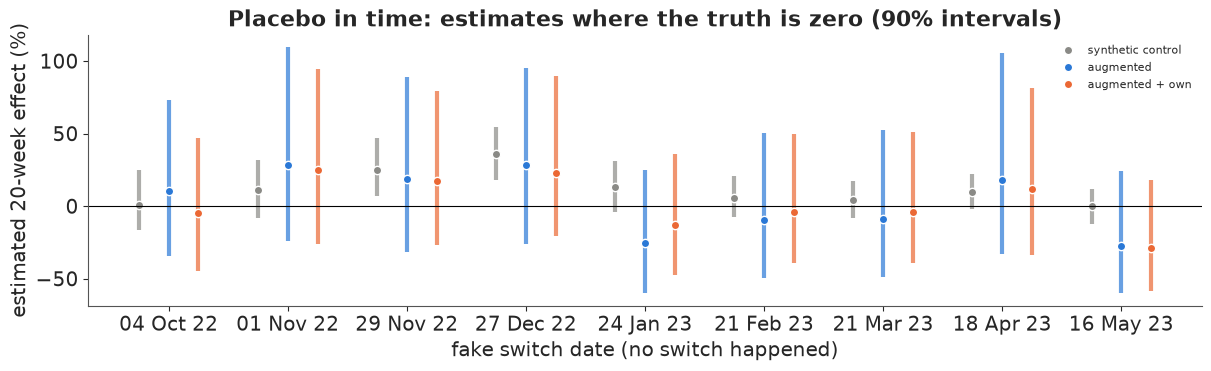

In [18]:
fig, ax = plt.subplots(figsize=(12, 3.6))
off = {"sc": -0.25, "aug": 0, "own": 0.25}
col = {"sc": GREY, "aug": BLUE, "own": ORANGE}
names = {"sc": "synthetic control", "aug": "augmented", "own": "augmented + own"}
for kind in off:
    d = tp[tp.model == kind]
    xs = np.arange(len(d)) + off[kind]
    ax.vlines(xs, d.q05 * 100, d.q95 * 100, color=col[kind], lw=3, alpha=0.7)
    ax.plot(xs, d["median"] * 100, "o", color=col[kind], mec="white", label=names[kind])
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(len(fake_dates)), [f.strftime("%d %b %y") for f in fake_dates])
ax.set(ylabel="estimated 20-week effect (%)", xlabel="fake switch date (no switch happened)",
       title="Placebo in time: estimates where the truth is zero (90% intervals)")
ax.legend(fontsize=8);

The classic control fails the test it was built to pass. At fake switch dates where nothing
happened, its 90% interval misses zero in 2 of 9 cases, and around the 2022 holidays it
reports "effects" of +25% to +35% with intervals that exclude zero. Its intervals are a third
as wide as the augmented ones - and wrong.

Both augmented versions contain zero every time, with intervals about 100 percentage points
wide; their point estimates err by 15-20% on average and by up to about 30%. The own-series
version is slightly tighter and slightly more accurate. Nine overlapping placebo windows are
not a precise calibration check, but they say something important: **with this data, a true
20-week effect smaller than about 30% in either direction cannot be told apart from noise.**

In [19]:
t_ = time.time()
COMPILED[("sc", J - 1)] = nutpie.compile_pymc_model(build_sc(*centre(X[:, 0], X[:, 1:], PRE)[:2], PRE))
_, _, Xs0 = centre(X[:, 0], X[:, 1:], PRE)
COMPILED[("own", J - 1)] = nutpie.compile_pymc_model(
    build_aug(centre(X[:, 0], X[:, 1:], PRE)[0], Xs0, PRE, (RX[:, 0] - RX[PRE, 0].mean()) / RX[PRE, 0].std()))
space, space_cf = [], {}
for j in range(J):
    keep = [i for i in range(J) if i != j]
    for kind in ["sc", "own"]:
        cf, div = run(kind, X[:, j], X[:, keep], RX[:, j], PRE, 11 + j)
        e = effect_pct(cf, X[:, j], POST)
        space.append({"donor": donor_label[j], "model": kind, "median": np.median(e), "q05": q(e)[0],
                      "q95": q(e)[2], "p_neg": (e < 0).mean(), "divergences": div})
        if kind == "own":
            space_cf[j] = np.quantile(cf, [0.05, 0.5, 0.95], axis=0)
sp = pd.DataFrame(space)
print(f"{len(sp)} placebo-in-space fits in {time.time() - t_:.0f} s; divergences in total: {sp.divergences.sum()}")
real = {"sc": pct_sc, "own": pct_own}
RANK = {}
for kind in ["sc", "own"]:
    d = sp[sp.model == kind]
    excl = ((d.q95 < 0) | (d.q05 > 0)).mean()
    rank = (d["median"] <= np.median(real[kind])).mean()
    RANK[kind] = rank
    print(f"{names[kind]:>18}: {excl:.0%} of the 21 untreated donors get a 90% interval excluding zero; "
          f"{rank:.0%} of them have an estimate at least as negative as the real one "
          f"({np.median(real[kind]):+.1%})")

42 placebo-in-space fits in 126 s; divergences in total: 7
 synthetic control: 62% of the 21 untreated donors get a 90% interval excluding zero; 19% of them have an estimate at least as negative as the real one (-25.7%)
   augmented + own: 24% of the 21 untreated donors get a 90% interval excluding zero; 24% of them have an estimate at least as negative as the real one (-12.6%)


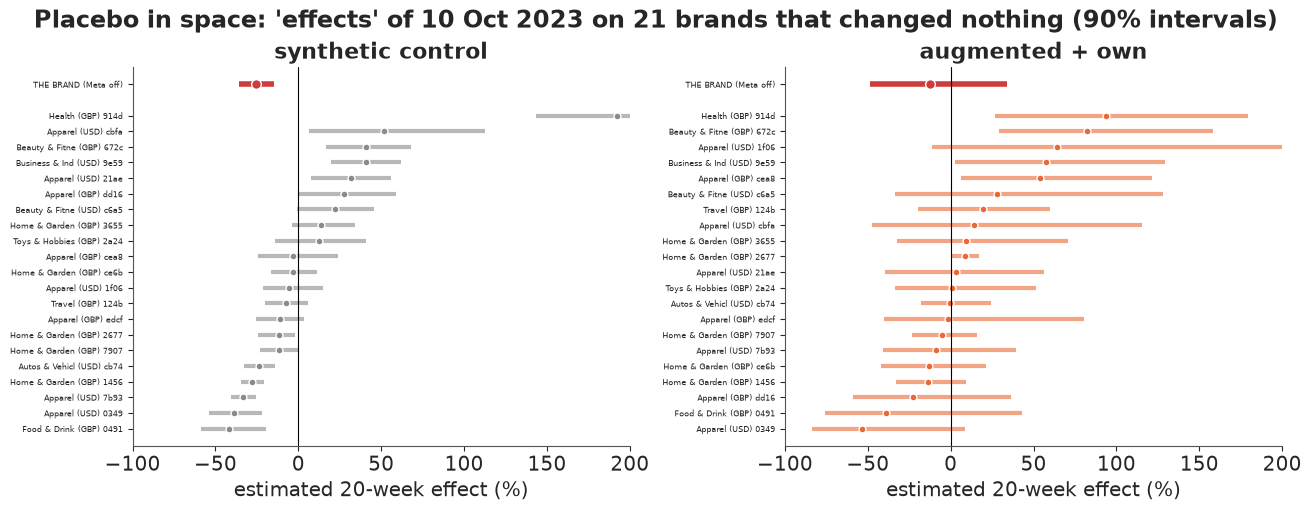

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for ax, kind in zip(axes, ["sc", "own"]):
    d = sp[sp.model == kind].sort_values("median").reset_index(drop=True)
    ax.hlines(range(J), d.q05 * 100, d.q95 * 100, color=col[kind], lw=3, alpha=0.6)
    ax.plot(d["median"] * 100, range(J), "o", color=col[kind], mec="white", ms=5)
    rq = q(real[kind]) * 100
    ax.hlines(J + 1, rq[0], rq[2], color=RED, lw=4)
    ax.plot(rq[1], J + 1, "o", color=RED, mec="white", ms=7)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_yticks([*range(J), J + 1], [*d.donor, "THE BRAND (Meta off)"], fontsize=6)
    ax.set(title=f"{names[kind]}", xlabel="estimated 20-week effect (%)")
    ax.set_xlim(-100, 200)
fig.suptitle("Placebo in space: 'effects' of 10 Oct 2023 on 21 brands that changed nothing (90% intervals)");

The same lesson from the other direction. Run on 21 brands that did nothing on 10 October
2023, the classic control finds a "significant" effect for more than half of them, some
larger than +50%. Its -26% for the real brand is unremarkable: about one in five untreated
brands gets an estimate at least as negative.

The augmented + own model is better behaved - about one in four donors gets an interval that
excludes zero (still more than the 1 in 10 a 90% interval promises; several donors have their
own campaign spikes or growth spurts after 10 October) - and the real brand's -13% sits in the middle of the
placebo distribution: about a quarter of the untreated brands show a drop at least as large.
As a permutation test, that is a p-value of roughly 0.25. Many donors are smaller and
noisier than the treated brand, which widens this reference distribution; but even allowing
for that, the real switch-off does not stand out.

In [21]:
cf_ret, div_ret = run("aug", R, X, None, PRE, 5, draws=1000)
e_ret = effect_pct(cf_ret, R, POST)
print(f"returning orders as the outcome: effect {np.median(e_ret):+.1%} "
      f"(90%: {q(e_ret)[0]:+.1%} to {q(e_ret)[2]:+.1%}), P(effect < 0) = {(e_ret < 0).mean():.2f}, "
      f"divergences {div_ret}")

returning orders as the outcome: effect -1.7% (90%: -39.1% to +56.4%), P(effect < 0) = 0.52, divergences 1


The brand's returning orders show no sign of a break: -2%, with an interval from about -40%
to +55% and P(effect < 0) = 0.52. Consistent with the assumption that the switch-off did not
move them - though with an interval this wide, the check could only have caught a large
shift.

**Sensitivity to the donor pool.** Rebuild the pool three ways and refit both the classic and
the augmented + own model: US-dollar donors only (the treated market's own calendar),
apparel brands only, and the full pool minus the donor the classic control leans on most.

In [22]:
pools = {
    "all 21 donors": list(range(J)),
    "US-dollar only": [j for j in range(J) if info.loc[DONORS[j], "currency"] == "USD"],
    "apparel only": [j for j in range(J) if info.loc[DONORS[j], "vertical"] == "Apparel"],
    f"without {donor_label[top[0]]}": [j for j in range(J) if j != top[0]],
}
sens = []
for pname, keep in pools.items():
    for kind in ["sc", "own"]:
        if (kind, len(keep)) not in COMPILED:
            yc_, Xc_, Xs_ = centre(Y, X[:, keep], PRE)
            COMPILED[(kind, len(keep))] = nutpie.compile_pymc_model(
                build_sc(yc_, Xc_, PRE) if kind == "sc" else build_aug(yc_, Xs_, PRE, Zr))
        cf, div = run(kind, Y, X[:, keep], R, PRE, 21, draws=1000)
        e = effect_pct(cf, Y, POST)
        sens.append({"donor pool": pname, "donors": len(keep), "model": names[kind],
                     "effect (median)": f"{np.median(e):+.0%}", "90% interval": f"{q(e)[0]:+.0%} to {q(e)[2]:+.0%}",
                     "P(effect < 0)": round((e < 0).mean(), 2), "divergences": div})
pd.DataFrame(sens)

,donor pool,donors,model,effect (median),90% interval,P(effect < 0),divergences
0,all 21 donors,21,synthetic control,-25%,-36% to -14%,1.00,0
1,all 21 donors,21,augmented + own,-15%,-48% to +33%,0.70,2
2,US-dollar only,8,synthetic control,-17%,-27% to -6%,0.99,0
3,US-dollar only,8,augmented + own,-15%,-48% to +33%,0.72,1
4,apparel only,8,synthetic control,-26%,-37% to -16%,1.00,0
5,apparel only,8,augmented + own,-14%,-49% to +37%,0.71,1
6,without Home & Garden (GBP) 1456,20,synthetic control,-31%,-41% to -21%,1.00,0
7,without Home & Garden (GBP) 1456,20,augmented + own,-15%,-48% to +36%,0.73,2


The classic control's answer depends on the donor pool: from -17% (US-dollar donors only) to
-31% (dropping its favourite donor), a 14-point spread, each time with an interval that
confidently excludes zero. The augmented + own model gives -14% to -15%
with almost the same interval whichever pool it gets. That robustness is less comforting
than it looks: the model ignores the donors, so of course it does not care which ones it is
given. Its answer rests on the brand's own history and returning-customer series.

## 7 · Showing it to the people who decide

A marketing lead wants to know whether switching off cost customers; finance wants to know
whether it saved money. Neither needs the words "posterior" or "interval". Five displays,
each drawn from the augmented + own model above (or from the placebo fits), in plain labels:

1. a fan chart of "what would have happened with Meta still on";
2. the running total of customers lost, with the chance that there was any loss at all;
3. a placebo line-up - the honest way to show that the effect is not clearly visible;
4. twenty equally likely outcomes, and the chance that switching off paid off, for any value
   of a new customer;
5. an icon array of 100 equally likely versions of the 20 weeks.

### 7.1 What would have happened if Meta had stayed on?

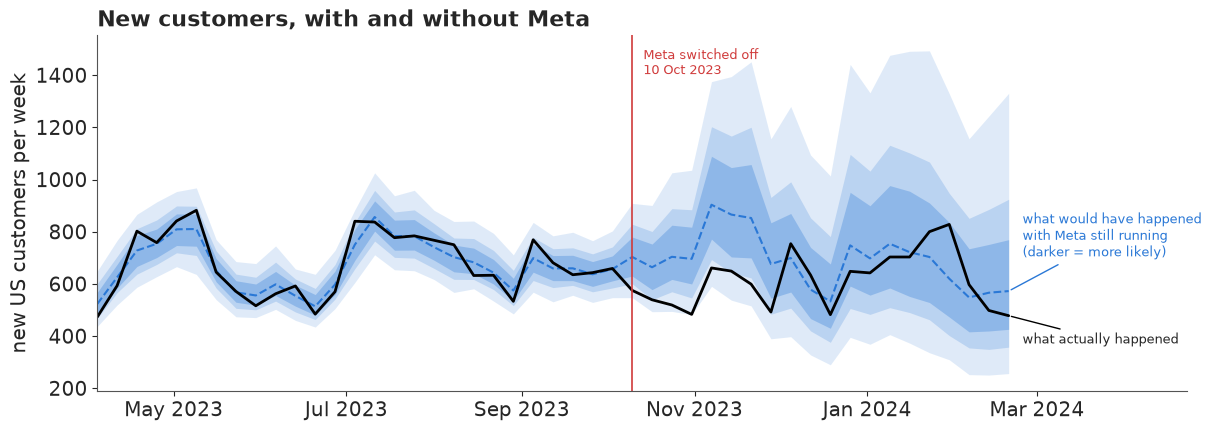

In [23]:
fig, ax = plt.subplots(figsize=(12, 4.2))
show = weeks >= pd.Timestamp("2023-04-01")
cfs = cf_own[:, show]
for lo_, hi_, al in [(0.05, 0.95, 0.15), (0.15, 0.85, 0.2), (0.25, 0.75, 0.3)]:
    ax.fill_between(weeks[show], *np.quantile(cfs, [lo_, hi_], axis=0), color=BLUE, alpha=al, lw=0)
ax.plot(weeks[show], np.median(cfs, axis=0), color=BLUE, lw=1.5, ls="--")
ax.plot(weeks[show], np.exp(Y[show]), color="k", lw=2)
ax.axvline(T0, color=RED, lw=1.2)
ax.annotate("Meta switched off\n10 Oct 2023", (T0, ax.get_ylim()[1] * 0.97), xytext=(8, 0),
            textcoords="offset points", va="top", color=RED, fontsize=9)
xl = weeks[POST][-1]
ax.annotate("what actually happened", (xl, np.exp(Y[POST][-1])), xytext=(10, -20),
            textcoords="offset points", fontsize=9, arrowprops={"arrowstyle": "-", "color": "k"})
ax.annotate("what would have happened\nwith Meta still running\n(darker = more likely)",
            (xl, np.median(cf_own[:, POST[-1]])), xytext=(10, 25), textcoords="offset points", fontsize=9,
            color=BLUE, arrowprops={"arrowstyle": "-", "color": BLUE})
ax.set_xlim(weeks[show][0], weeks[-1] + pd.Timedelta(weeks=9))
ax.set(ylabel="new US customers per week")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_title("New customers, with and without Meta", loc="left");

### 7.2 Customers lost so far, and how sure we are that there was any loss

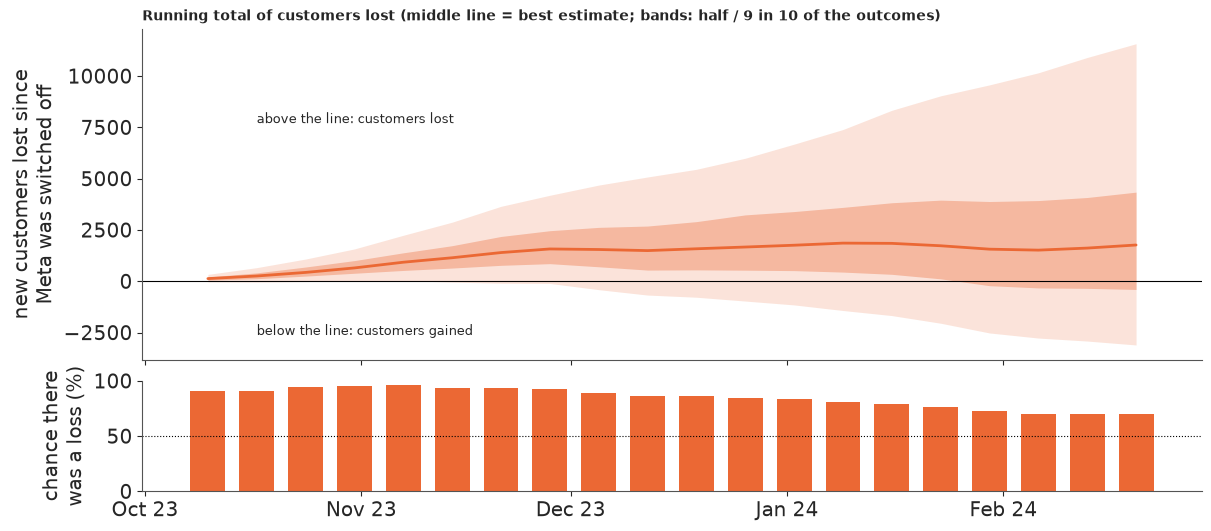

In [24]:
p_loss = (lost_cum > 0).mean(axis=0)
fig, axes = plt.subplots(2, 1, figsize=(12, 5.2), sharex=True, height_ratios=[3, 1])
ax = axes[0]
for lo_, hi_, al in [(0.05, 0.95, 0.18), (0.25, 0.75, 0.35)]:
    ax.fill_between(wk_post, *np.quantile(lost_cum, [lo_, hi_], axis=0), color=ORANGE, alpha=al, lw=0)
ax.plot(wk_post, np.median(lost_cum, axis=0), color=ORANGE, lw=2)
ax.axhline(0, color="k", lw=0.8)
ax.text(wk_post[1], np.quantile(lost_cum[:, -1], 0.9), "above the line: customers lost", fontsize=9)
ax.text(wk_post[1], np.quantile(lost_cum[:, -1], 0.08), "below the line: customers gained", fontsize=9)
ax.set(ylabel="new customers lost since\nMeta was switched off")
ax.set_title("Running total of customers lost (middle line = best estimate; bands: half / 9 in 10 of the outcomes)",
             loc="left", fontsize=10)
axes[1].bar(wk_post, p_loss * 100, width=5, color=np.where(p_loss > 0.5, ORANGE, GREY))
axes[1].axhline(50, color="k", lw=0.8, ls=":")
axes[1].set(ylabel="chance there\nwas a loss (%)", ylim=(0, 100))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %y"));

### 7.3 The placebo line-up: can you spot the real switch-off?

Eleven panels: ten brands that changed nothing on 10 October 2023, each with the model's
"what would have happened" band, and our brand, which switched Meta off. The panel order is
shuffled; the answer is printed below the figure. If you cannot pick the real one out, the
data cannot either.

answer: brand I


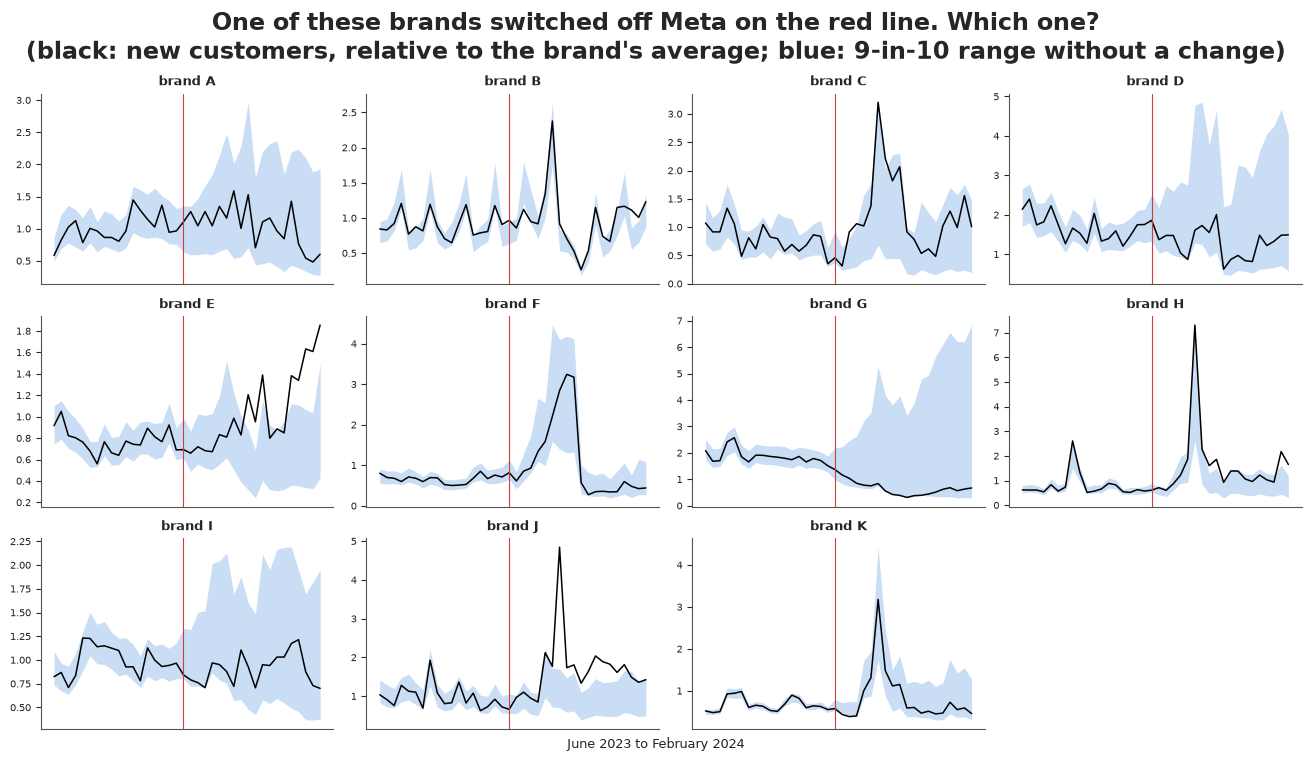

In [25]:
lr = np.random.default_rng(3)
picks = list(lr.choice(J, 10, replace=False))
panels = [("real", None)] + [("placebo", j) for j in picks]
order = lr.permutation(len(panels))
fig, axes = plt.subplots(3, 4, figsize=(13, 7.5))
sl_ = weeks >= pd.Timestamp("2023-06-01")
for n, ax in enumerate(axes.ravel()):
    if n >= len(panels):
        ax.axis("off")
        continue
    kind, j = panels[order[n]]
    y_, band = (Y, np.quantile(cf_own, [0.05, 0.5, 0.95], axis=0)) if kind == "real" else (X[:, j], space_cf[j])
    scale = np.exp(y_[PRE]).mean()
    ax.fill_between(weeks[sl_], band[0, sl_] / scale, band[2, sl_] / scale, color=BLUE, alpha=0.25, lw=0)
    ax.plot(weeks[sl_], np.exp(y_[sl_]) / scale, color="k", lw=1.1)
    ax.axvline(T0, color=RED, lw=0.8)
    ax.set_title(f"brand {chr(65 + n)}", fontsize=9)
    ax.set_xticks([])
    ax.tick_params(labelsize=7)
fig.suptitle("One of these brands switched off Meta on the red line. Which one?\n"
             "(black: new customers, relative to the brand's average; blue: 9-in-10 range without a change)")
fig.supxlabel("June 2023 to February 2024", fontsize=9);
print("answer: brand", chr(65 + int(np.flatnonzero(order == 0)[0])))

### 7.4 Was switching Meta off worth it? Twenty equally likely answers

Left: a quantile dotplot of the customers lost over the 20 weeks - twenty dots, each a 1-in-20
chance. Right: the question finance asks, as a curve. If a new customer is worth $V$ to the
brand (margin over their lifetime), switching off was the right call when the customers lost,
times $V$, are less than the Meta money saved. The curve gives the chance of that for every
$V$, with the money saved at the 8-week run rate (solid) or at last year's spend for the same
weeks (dashed).

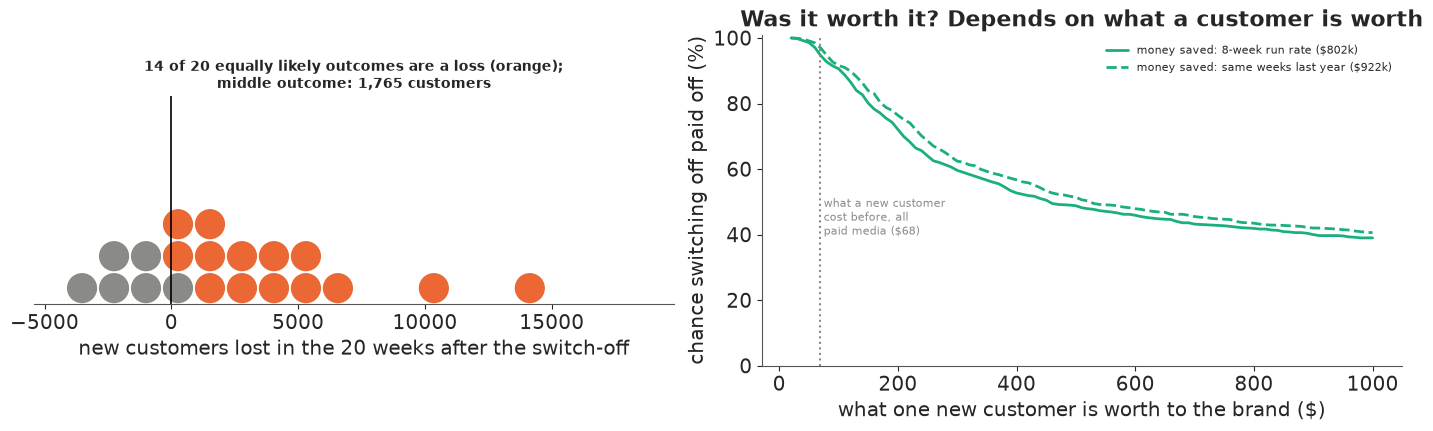

In [26]:
def quantile_dotplot(ax, samples, n_dots=20, n_bins=20, color=ORANGE, xlim=None, max_stack=6):
    """Wilkinson-style dotplot of the n_dots quantiles of `samples` (as in E16 and E33)."""
    qd = np.quantile(samples, (np.arange(n_dots) + 0.5) / n_dots)
    lo_, hi_ = xlim if xlim is not None else (qd.min(), qd.max())
    edges = np.linspace(lo_, hi_, n_bins + 1)
    width = edges[1] - edges[0]
    cols = np.clip(np.digitize(qd, edges) - 1, 0, n_bins - 1)
    heights = np.zeros(n_bins, int)
    for cix, v in zip(cols, qd):
        ax.add_patch(Ellipse((edges[cix] + width / 2, heights[cix] + 0.5), width * 0.9, 0.9,
                             color=color if v > 0 else GREY))
        heights[cix] += 1
    ax.set(xlim=(lo_, hi_), ylim=(0, max_stack + 0.5), yticks=[])
    ax.set_aspect(width)
    sns.despine(ax=ax, left=True)
    return qd


values = np.linspace(20, 1000, 99)
p_worth = {k: np.array([(LOST * v < s).mean() for v in values]) for k, s in SAVED.items()}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
span = np.quantile(LOST, [0.01, 0.99])
qd = quantile_dotplot(axes[0], LOST, xlim=(span[0] * 1.1, span[1] * 1.1))
axes[0].axvline(0, color="k", lw=1.2)
axes[0].set_xlabel("new customers lost in the 20 weeks after the switch-off")
axes[0].set_title(f"{int((qd > 0).sum())} of 20 equally likely outcomes are a loss (orange);\n"
                  f"middle outcome: {np.median(LOST):,.0f} customers", fontsize=10)
for (k, pw), ls in zip(p_worth.items(), ["-", "--"]):
    axes[1].plot(values, pw * 100, color=AQUA, ls=ls, lw=2, label=f"money saved: {k} (${SAVED[k] / 1e3:,.0f}k)")
axes[1].axvline(blended_cac, color=GREY, ls=":")
axes[1].text(blended_cac, 40, f" what a new customer\n cost before, all\n paid media (${blended_cac:.0f})",
             fontsize=8, color=GREY)
axes[1].set(xlabel="what one new customer is worth to the brand ($)", ylabel="chance switching off paid off (%)",
            ylim=(0, 101), title="Was it worth it? Depends on what a customer is worth")
axes[1].legend(fontsize=8, loc="upper right");

### 7.5 A hundred possible versions of the 20 weeks

An icon array for the one number people remember: out of 100 equally likely versions of
what happened, in how many did the switch-off lose customers - and in how many more than
1,000 (roughly two average weeks)?

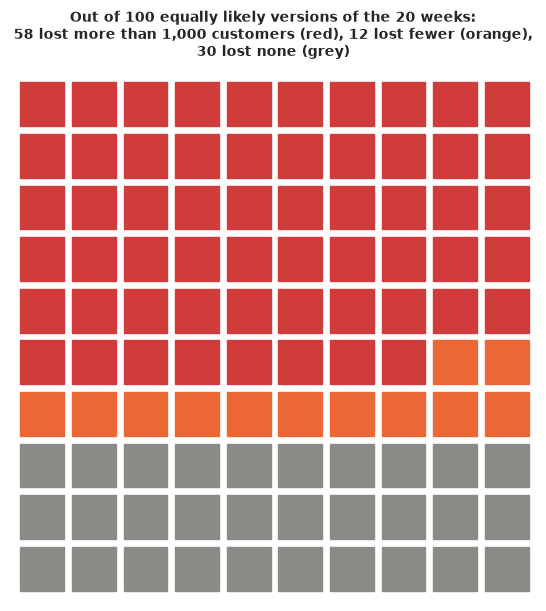

In [27]:
n_any = int(round(100 * (LOST > 0).mean()))
n_big = int(round(100 * (LOST > 1000).mean()))
fig, ax = plt.subplots(figsize=(6, 6))
for k in range(100):
    c = RED if k < n_big else (ORANGE if k < n_any else GREY)
    ax.add_patch(Rectangle((k % 10, 9 - k // 10), 0.85, 0.85, color=c))
ax.set(xlim=(-0.2, 10), ylim=(-0.2, 10.2), aspect=1, xticks=[], yticks=[])
sns.despine(ax=ax, left=True, bottom=True)
ax.set_title(f"Out of 100 equally likely versions of the 20 weeks:\n"
             f"{n_big} lost more than 1,000 customers (red), {n_any - n_big} lost fewer (orange),\n"
             f"{100 - n_any} lost none (grey)", fontsize=10);

What each display is for, and what it says here:

- **The fan chart** gives the counterfactual the name people use ("what would have happened")
  and lets the shading carry the uncertainty: close to the switch the observed line runs
  below the likeliest shades; by February it sits inside them.
- **The running total** answers "how many did we lose?" and, underneath, "are we even sure we
  lost any?" - the chance of a loss is above 90% for most of October and November and drifts
  down to about 70% by late February, as the loss stops growing and the counterfactual
  widens.
- **The line-up** is the most honest display in the notebook. Several of the brands that did
  nothing show bigger departures from their bands than our brand does; if a reader cannot
  spot the real one, the data do not "clearly show" an effect, whatever the headline says.
- **The dotplot and the curve** turn the customer count into the decision. About 14 of 20
  equally likely outcomes are a loss; but if a new customer is worth less than about $100 to
  the brand, the chance that switching off paid off is about 9 in 10 or better, and at $500
  per customer it is roughly a coin flip.
- **The icon array** puts the one number people remember - the chance of any loss - next to
  the chance of a loss big enough to matter (more than 1,000 customers).

### 7.6 Export for the web page

In [28]:
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sub = rng.choice(len(LOST), 300, replace=False)
qs = [0.05, 0.25, 0.5, 0.75, 0.95]
qdict = lambda a: {f"q{int(100 * p):02d}": np.quantile(a, p, axis=0).round(1).tolist() for p in qs}
cpl_q = np.quantile(SAVED["8-week run rate"] / LOST[LOST > 0], [0.05, 0.5, 0.95])
export = {
    "id": "E34",
    "title": "Did switching off Meta cost customers? A synthetic-control reading of a real switch-off",
    "brand": "UK women's-apparel brand, US market (anonymised, Conjura open MMM data, CC BY 4.0)",
    "intervention": {"what": "all Meta advertising stopped", "date": str(T0.date()), "market": "US",
                     "meta_spend_before_usd_per_week": round(meta_rate)},
    "caveat": ("Observational natural experiment, not a randomised test: the brand chose when to switch off, "
               "Meta also stopped in its UK market the same day, and the data cannot rule out a lost "
               "Meta data connection instead of a real pause."),
    "weeks": [str(d.date()) for d in weeks], "switch_week_index": int(POST[0]),
    "observed_new_customers": np.exp(Y).round(0).astype(int).tolist(),
    "counterfactual_new_customers": {"unit": "new customers per week if Meta had stayed on", **qdict(cf_own)},
    "cumulative_lost": {"unit": "new customers lost since the switch (positive = lost)",
                        "weeks": [str(d.date()) for d in wk_post], **qdict(lost_cum),
                        "p_any_loss": p_loss.round(3).tolist()},
    "total_lost_20_weeks": {"draws": LOST[sub].round(0).astype(int).tolist(), "median": float(np.median(LOST)),
                            "q05": float(q(LOST)[0]), "q95": float(q(LOST)[2]), "p_loss": float((LOST > 0).mean()),
                            "p_loss_over_1000": float((LOST > 1000).mean())},
    "effect_pct_20_weeks": {"median": float(np.median(pct_own)), "q05": float(q(pct_own)[0]),
                            "q95": float(q(pct_own)[2])},
    "money_saved_usd": {k: round(v) for k, v in SAVED.items()},
    "blended_cost_per_new_customer_before_usd": round(blended_cac, 1),
    "cost_per_lost_customer_usd_given_a_loss": dict(zip(["q05", "q50", "q95"], cpl_q.round(0).tolist())),
    "p_switch_off_paid_off": {"customer_value_usd": values.round(0).tolist(),
                              **{k: v.round(3).tolist() for k, v in p_worth.items()}},
    "model_comparison": {names[k]: {"median": float(np.median(v)), "q05": float(q(v)[0]), "q95": float(q(v)[2])}
                         for k, v in [("sc", pct_sc), ("aug", pct_aug), ("own", pct_own)]},
    "placebo_in_time": tp.assign(**{"fake switch": tp["fake switch"].astype(str)}).round(3).to_dict(orient="records"),
    "placebo_in_space": sp.round(3).to_dict(orient="records"),
    "placebo_in_space_share_as_negative": RANK,
    "headlines": {},
}
export["headlines"] = HEADLINES = {
    "effect": (f"Without Meta, US new customers over the next 20 weeks were most likely about "
               f"{abs(np.median(pct_own)):.0%} {'lower' if np.median(pct_own) < 0 else 'higher'} than they would "
               f"otherwise have been, but anything from {q(pct_own)[0]:+.0%} to {q(pct_own)[2]:+.0%} is plausible."),
    "lost": (f"Best estimate: about {round(np.median(LOST), -2):,.0f} new customers lost in 20 weeks; the chance that any "
             f"were lost at all is {(LOST > 0).mean():.0%}."),
    "money": (f"Switching off saved roughly ${SAVED['8-week run rate'] / 1e3:,.0f}k of Meta spend. If customers were lost, "
              f"each one cost about ${round(cpl_q[1], -1):,.0f} of that spend (9 in 10 chance: ${round(cpl_q[0], -1):,.0f} to ${round(cpl_q[2], -2):,.0f})"
              f" - against ${blended_cac:.0f} per new customer across all paid media before."),
    "placebo": (f"Run on 21 brands that changed nothing that day, the same model finds a drop at least this "
                f"large for {RANK['own']:.0%} of them: this switch-off cannot be told apart from ordinary ups and "
                f"downs."),
    "caveat": export["caveat"],
}
out = root / ".scratch" / "artifact" / "E34.json"
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps(export, separators=(",", ":"), default=float))
print(f"wrote {out.relative_to(root)} ({out.stat().st_size / 1024:.0f} KB)")
for v in HEADLINES.values():
    print("-", v)

wrote .scratch/artifact/E34.json (21 KB)
- Without Meta, US new customers over the next 20 weeks were most likely about 13% lower than they would otherwise have been, but anything from -49% to +34% is plausible.
- Best estimate: about 1,800 new customers lost in 20 weeks; the chance that any were lost at all is 70%.
- Switching off saved roughly $802k of Meta spend. If customers were lost, each one cost about $240 of that spend (9 in 10 chance: $60 to $2,100) - against $68 per new customer across all paid media before.
- Run on 21 brands that changed nothing that day, the same model finds a drop at least this large for 24% of them: this switch-off cannot be told apart from ordinary ups and downs.
- Observational natural experiment, not a randomised test: the brand chose when to switch off, Meta also stopped in its UK market the same day, and the data cannot rule out a lost Meta data connection instead of a real pause.


## What to take away

- **Look for natural experiments systematically, then argue against the best one.** A
  change-point scan of channel spend found two dozen candidates; the best of them still has a
  self-chosen date, no within-brand control, Black Friday in the window and a possible data
  artefact. Write those down before the first model is fitted.
- **A synthetic control is only as good as its pre-period fit.** With donors that do not
  track the treated unit, the classic simplex control gave a precise, donor-dependent and
  wrong-looking answer; iid noise made its 20-week sum far too certain.
- **The augmented / structural version is the honest default**: a sparse regression on donors
  plus a local level for what they miss. Integrate the level out (a random walk is a Gaussian
  process) - it removes the noise-versus-level ridge that makes the latent version mix badly.
- **Placebos are the test, not the fan chart.** In-time placebos measured how large an effect
  must be before it can be seen (about 30% over 20 weeks here); in-space placebos put the real
  estimate in the middle of what untreated brands show. A good-looking counterfactual that
  fails its placebos is not evidence.
- **The decision can be clearer than the effect.** The loss in customers is uncertain, but
  $800,000 of spend was saved, and the posterior makes it very unlikely that Meta was buying
  customers at anything like the brand's blended cost. "Probably worth switching off unless a
  customer is worth several hundred dollars" is a useful answer from an inconclusive effect.
- The next step is the one E33 ended with: a **randomised** geo test (switch Meta back on in a
  few US states for eight weeks) would answer in two months what this natural experiment
  cannot.

## Try it yourself

1. **The UK replication.** The same brand switched Meta off in the UK on the same day (its UK
   series ends on 8 February 2024, so use 17 post-period weeks and sterling donors). Does the
   UK tell the same story? Then fit both markets jointly with a shared effect (in percent) and
   market-specific levels: two noisy natural experiments pooled are worth more than one.
2. **A switch-on.** An Australian apparel brand (`7c374835`) launched Meta at the end of July
   2022 while also raising Google spend. Repeat the analysis with Australian-dollar donors from
   other brands - and notice that its own New Zealand series also launched Meta that week, so it is
   not a donor. What does the effect estimate mean when two channels change at once?
3. **Seasonality for what donors miss.** Add yearly Fourier terms (or last year's value of the
   treated series) to the augmented model and re-run the placebos in time. Do the intervals
   narrow without losing coverage? That trade - narrower but still calibrated - is the only
   honest way to a sharper answer from the same natural experiment.